# 07 - Responsible ML Checks

## Objective

The purpose of this notebook is to evaluate the trained CatBoost model from a Responsible Machine Learning perspective by examining model performance across different demographic groups present in the dataset.

The analysis focuses on group-wise performance evaluation for the sensitive attributes available in the Adult Income dataset, specifically **sex** and **race**.

This assessment helps determine whether the model performs consistently across groups and identifies any meaningful differences in predictive performance.

> This analysis is performed solely for educational purposes and model evaluation. The model is not intended for real-world decision-making involving employment, hiring, lending, or other high-impact domains.

---

## Tasks Performed

### 1. Load Saved Model and Test Data

- Loaded the final tuned CatBoost model.
- Loaded the untouched test dataset.
- Prepared features and target variables for evaluation.

### 2. Generate Test Predictions

- Generated predicted class labels using the selected threshold.
- Generated prediction probabilities for performance analysis.

### 3. Group-wise Evaluation by Sex

- Evaluated model performance separately for Male and Female groups.
- Calculated:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
- Compared performance across sex categories.

### 4. Group-wise Evaluation by Race

- Evaluated model performance separately for each race category.
- Calculated:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
- Compared performance across racial groups.

### 5. Responsible ML Assessment

- Examined whether notable performance differences exist between groups.
- Documented observations and limitations.
- Highlighted that group-level evaluation does not imply fairness certification.

---

## Key Results

The model demonstrated generally strong predictive performance across both sex and race groups.

### Sex-Based Performance

| Sex | Accuracy | Precision | Recall | F1 Score |
|------|----------|-----------|---------|----------|
| Male | 83.23% | 70.68% | 75.31% | 72.92% |
| Female | 93.52% | 72.01% | 66.27% | 69.02% |

### Race-Based Performance

| Race | Accuracy | Precision | Recall | F1 Score |
|--------|----------|-----------|---------|----------|
| Black | 93.02% | 71.60% | 64.80% | 68.04% |
| White | 85.89% | 70.71% | 74.50% | 72.55% |
| Asian-Pac-Islander | 84.58% | 70.92% | 75.19% | 72.99% |
| Other | 91.85% | 93.75% | 60.00% | 73.17% |
| Amer-Indian-Eskimo | 93.08% | 75.00% | 63.16% | 68.57% |

The results indicate that model performance varies across demographic groups, particularly in recall and F1-score. These differences should be carefully considered when interpreting model behavior.

---

## Outcome

At the completion of this notebook, the CatBoost model has been evaluated across sensitive demographic groups using group-wise performance metrics.

The analysis provides transparency into model behavior across different populations and supports responsible reporting of machine learning results while acknowledging that performance differences may exist between groups.

## Load Test Data

### Objective

The purpose of this section is to load the preprocessed testing dataset that will be used for responsible machine learning evaluation.

The testing dataset contains the final unseen observations and will be used to assess model performance across different demographic groups.

After this step:

- The testing dataset will be loaded successfully.
- Dataset dimensions and structure will be verified.
- The data will be ready for group-wise performance analysis.

In [77]:
import pandas as pd
adult_test_clean = pd.read_csv(
    "adult_test_clean.csv"
)
adult_test_clean.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0


## Load Final Tuned Model

### Objective

The purpose of this section is to load the final tuned CatBoost model that was selected during hyperparameter optimization and threshold tuning.

This model will be used to generate predictions for responsible machine learning assessment.

### Expected Outcome

After this step:

- The saved CatBoost model will be loaded successfully.
- The model will be ready to generate predictions on the testing dataset.
- No retraining will be required.

In [78]:
!pip install catboost
from catboost import CatBoostClassifier
final_model = CatBoostClassifier()
final_model.load_model(
    "catboost_income_model.cbm"
)

CatBoostClassifier(bagging_temperature=0, depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, loss_function='Logloss', od_type='Iter', od_wait=100, one_hot_max_size=2, random_seed=42, random_strength=1, use_best_model=True, verbose=100)

In [79]:
print(type(final_model))

<class 'catboost.core.CatBoostClassifier'>


## Generate Final Predictions

### Objective

The purpose of this section is to generate final predictions using the selected classification threshold obtained during threshold optimization.

Using the same threshold ensures consistency between model evaluation and responsible machine learning assessment.

### Selected Threshold

The threshold selected in the previous notebook was:

- 0.40

This threshold achieved the highest F1-Score and provided the best balance between precision and recall.

### Expected Outcome

After this step:

- Prediction probabilities will be generated.
- Final class predictions will be created.
- Results will be ready for group-wise evaluation.

In [80]:
X_test = adult_test_clean.drop(
    'income',
    axis=1
)
y_test = adult_test_clean['income']

In [81]:
y_test_proba = final_model.predict_proba(
    X_test
)[:, 1]

In [82]:
optimal_threshold = 0.40
y_test_pred = (
    y_test_proba >= optimal_threshold
).astype(int)

In [83]:
pd.Series(y_test_pred).value_counts()

,count
0,12264
1,4012


## Create Evaluation Dataset

### Objective

The purpose of this section is to create a consolidated evaluation dataset containing actual labels, predicted labels, and demographic attributes.

This dataset will be used to calculate group-wise performance metrics for responsible machine learning assessment.

### Included Information

The evaluation dataset contains:

- Actual Income Label
- Predicted Income Label
- Sex
- Race

### Expected Outcome

After this step:

- A dedicated evaluation dataset will be available.
- Group-wise performance analysis can be performed efficiently.
- The dataset will support responsible ML reporting.

In [84]:
evaluation_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Sex': adult_test_clean['sex'],
    'Race': adult_test_clean['race']
})
evaluation_df.head()

,Actual,Predicted,Sex,Race
0,0,0,Male,Black
1,0,0,Male,White
2,1,1,Male,White
3,1,1,Male,Black
4,0,0,Female,White


In [85]:
evaluation_df.shape

(16276, 4)

In [86]:
evaluation_df['Sex'].value_counts()

,count
Sex,
Male,10856
Female,5420


In [87]:
evaluation_df['Race'].value_counts()

,count
Race,
White,13941
Black,1561
Asian-Pac-Islander,480
Amer-Indian-Eskimo,159
Other,135


## Group-wise Evaluation by Sex

### Objective

The purpose of this section is to evaluate model performance separately for different sex groups.

Performance metrics will be calculated independently for:

- Male
- Female

This analysis helps determine whether model performance varies substantially across groups.

### Metrics Evaluated

- Accuracy
- Precision
- Recall
- F1-Score

### Expected Outcome

After this step:

- Group-wise performance metrics will be available.
- Potential performance differences between groups can be observed.
- Results will support responsible machine learning reporting.

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
sex_results = []
for sex in evaluation_df['Sex'].unique():

    group = evaluation_df[
        evaluation_df['Sex'] == sex
    ]
    sex_results.append([
        sex,
        accuracy_score(
            group['Actual'],
            group['Predicted']
        ),
        precision_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        ),
        recall_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        ),
        f1_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        )
    ])
sex_metrics = pd.DataFrame(
    sex_results,
    columns=[
        'Sex',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)
sex_metrics.round(4)

,Sex,Accuracy,Precision,Recall,F1 Score
0,Male,0.8323,0.7068,0.7531,0.7292
1,Female,0.9352,0.7201,0.6627,0.6902


## Group-wise Evaluation by Race

### Objective

The purpose of this section is to evaluate model performance separately across race groups.

Performance metrics will be calculated independently for each race category to identify whether model performance differs substantially across groups.

### Metrics Evaluated

- Accuracy
- Precision
- Recall
- F1-Score

### Expected Outcome

After this step:

- Group-wise performance metrics for race categories will be available.
- Performance differences across groups can be examined.
- Results will contribute to the responsible machine learning assessment.

In [89]:
race_results = []
for race in evaluation_df['Race'].unique():
    group = evaluation_df[
        evaluation_df['Race'] == race
    ]
    race_results.append([
        race,
        accuracy_score(
            group['Actual'],
            group['Predicted']
        ),
        precision_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        ),
        recall_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        ),
        f1_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        )
    ])
race_metrics = pd.DataFrame(
    race_results,
    columns=[
        'Race',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)
race_metrics.round(4)

,Race,Accuracy,Precision,Recall,F1 Score
0,Black,0.9302,0.7160,0.6480,0.6804
1,White,0.8589,0.7071,0.7450,0.7255
2,Asian-Pac-Islander,0.8458,0.7092,0.7519,0.7299
3,Other,0.9185,0.9375,0.6000,0.7317
4,Amer-Indian-Eskimo,0.9308,0.7500,0.6316,0.6857


## Additional Fairness Metrics

### Objective

Beyond overall predictive performance, it is important to evaluate how the model behaves across demographic groups.

This section examines:

- Area Under the ROC Curve (AUC)
- Recall
- False Positive Rate (FPR)
- False Negative Rate (FNR)

for different sex and race groups.

These metrics help identify whether the model exhibits substantially different error patterns across demographic categories.

The results should be interpreted carefully, as differences may arise from sample size variation, class imbalance, historical patterns in the dataset, or feature distributions.

In [90]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    recall_score
)
sex_fairness_results = []
for sex in evaluation_df['Sex'].unique():
    group = evaluation_df[
        evaluation_df['Sex'] == sex
    ]
    # corresponding probabilities
    group_proba = y_test_proba[
        evaluation_df['Sex'] == sex
    ]
    tn, fp, fn, tp = confusion_matrix(
        group['Actual'],
        group['Predicted']
    ).ravel()
    auc = roc_auc_score(
        group['Actual'],
        group_proba
    )
    recall = recall_score(
        group['Actual'],
        group['Predicted']
    )
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    sex_fairness_results.append([
        sex,
        auc,
        recall,
        fpr,
        fnr
    ])
sex_fairness_metrics = pd.DataFrame(
    sex_fairness_results,
    columns=[
        'Sex',
        'AUC',
        'Recall',
        'FPR',
        'FNR'
    ]
)
sex_fairness_metrics.round(4)

,Sex,AUC,Recall,FPR,FNR
0,Male,0.9098,0.7531,0.1338,0.2469
1,Female,0.9460,0.6627,0.0315,0.3373


In [91]:
race_fairness_results = []
for race in evaluation_df['Race'].unique():
    group = evaluation_df[
        evaluation_df['Race'] == race
    ]
    group_proba = y_test_proba[
        evaluation_df['Race'] == race
    ]
    tn, fp, fn, tp = confusion_matrix(
        group['Actual'],
        group['Predicted']
    ).ravel()
    auc = roc_auc_score(
        group['Actual'],
        group_proba
    )
    recall = recall_score(
        group['Actual'],
        group['Predicted']
    )
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    race_fairness_results.append([
        race,
        auc,
        recall,
        fpr,
        fnr
    ])
race_fairness_metrics = pd.DataFrame(
    race_fairness_results,
    columns=[
        'Race',
        'AUC',
        'Recall',
        'FPR',
        'FNR'
    ]
)
race_fairness_metrics.round(4)

,Race,AUC,Recall,FPR,FNR
0,Black,0.9483,0.6480,0.0333,0.3520
1,White,0.9240,0.7450,0.1031,0.2550
2,Asian-Pac-Islander,0.9104,0.7519,0.1182,0.2481
3,Other,0.9749,0.6000,0.0091,0.4000
4,Amer-Indian-Eskimo,0.9515,0.6316,0.0286,0.3684


**Interpretation of Fairness Metrics**

### Sex-Based Evaluation

The model achieved higher AUC for females (0.9460) than males (0.9098), indicating stronger ranking performance for female individuals.

Recall was higher for males (0.7531) than females (0.6627), meaning the model identified a larger proportion of high-income male individuals.

The False Positive Rate (FPR) was substantially lower for females (0.0315) compared with males (0.1338), suggesting that low-income female individuals were less likely to be incorrectly classified as high-income.

The False Negative Rate (FNR) was higher for females (0.3373) than males (0.2469), indicating that the model missed a larger proportion of high-income female individuals.

### Race-Based Evaluation

AUC values remained above 0.90 across all race groups, indicating strong overall discrimination capability.

Recall varied across race categories, ranging from approximately 0.60 to 0.75. The highest recall was observed for Asian-Pac-Islander individuals (0.7519), while the lowest recall was observed for the Other category (0.6000).

False Positive Rates were generally low across race groups, though White (0.1031) and Asian-Pac-Islander (0.1182) groups experienced relatively higher values.

False Negative Rates ranged between approximately 0.25 and 0.40, indicating variation in the model's ability to correctly identify high-income individuals across demographic groups.

### Discussion

Observed differences in performance metrics may result from variations in sample size, class distributions, historical socioeconomic patterns, and feature distributions present in the dataset.

These results do not necessarily imply unfairness; however, they highlight the importance of monitoring model behavior across demographic groups.

Because the Adult Census dataset contains sensitive demographic attributes, this model should not be used for real-world employment, lending, admissions, or other high-impact decisions without appropriate governance, auditing, and fairness assessments.

## Visualize Group Performance

### Objective

The purpose of this section is to visualize model performance across demographic groups.

Visual comparisons make it easier to identify potential performance differences and support responsible machine learning reporting.

### Visualizations

The following comparisons will be created:

- Performance by Sex
- Performance by Race

Metrics visualized:

- Accuracy
- Precision
- Recall
- F1-Score

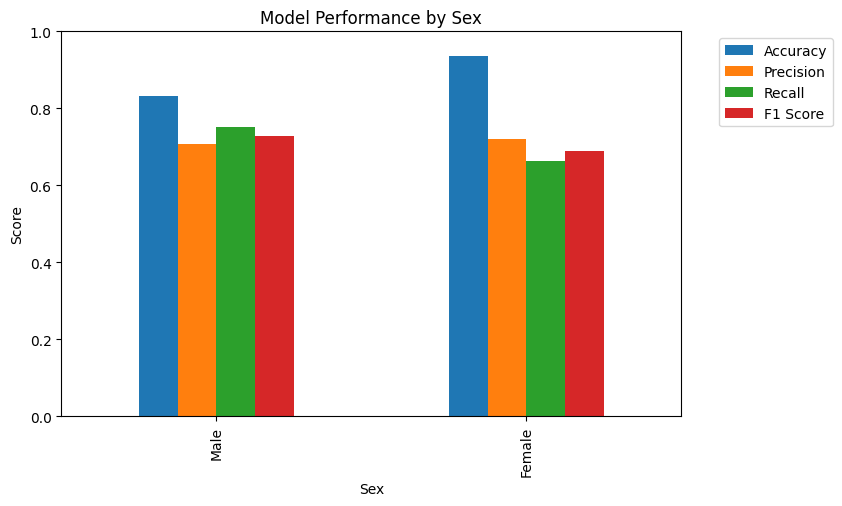

In [92]:
import matplotlib.pyplot as plt
sex_metrics_plot = sex_metrics.set_index('Sex')
sex_metrics_plot.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Model Performance by Sex')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()

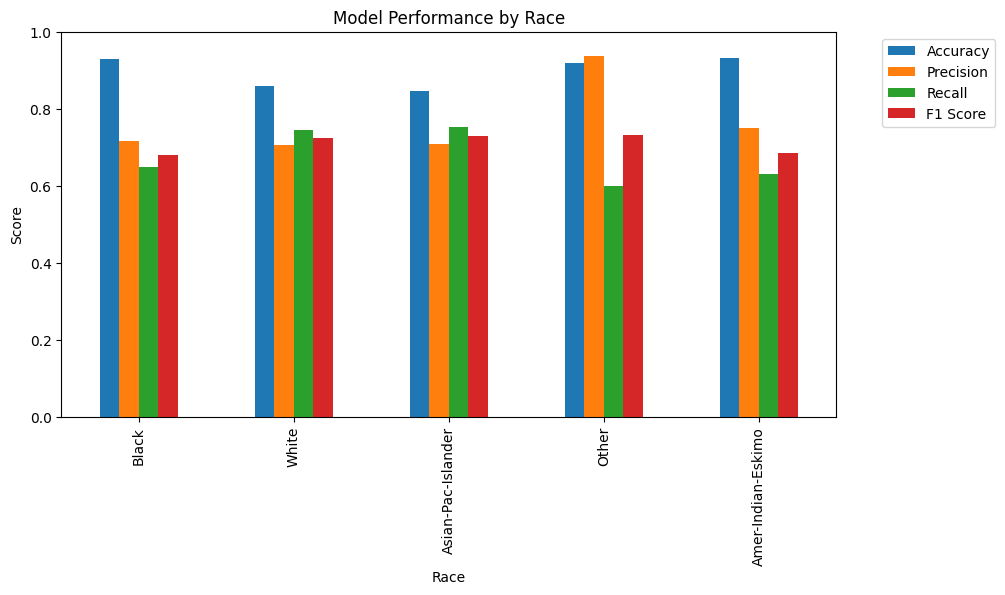

In [93]:
race_metrics_plot = race_metrics.set_index('Race')
race_metrics_plot.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Model Performance by Race')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()

## Responsible ML Discussion

### Objective

The purpose of this section is to examine model performance across demographic groups and document observations in a responsible and transparent manner.

### Performance by Sex

The model achieved different performance levels across sex groups.

- Female observations achieved higher overall accuracy (93.52%) than male observations (83.23%).
- Precision was relatively similar across both groups.
- Recall was higher for males (75.31%) than females (66.27%).
- The F1-score was slightly higher for males (72.92%) than females (69.02%).

These differences indicate that model performance is not perfectly uniform across sex groups.

### Performance by Race

Performance metrics also varied across race groups.

- White and Asian-Pac-Islander groups achieved the highest recall values.
- Black and Amer-Indian-Eskimo groups achieved lower recall values.
- Precision values remained relatively similar across most race categories.
- Some race categories contain substantially fewer observations than others, which may contribute to metric variability.

### Important Considerations

The observed differences do not necessarily indicate bias or unfairness. Performance differences may arise from:

- Differences in sample sizes across groups.
- Differences in feature distributions.
- Class imbalance within demographic groups.
- Limitations of the underlying dataset.

### Responsible Use Statement

This project was developed solely for educational and learning purposes.

The model should not be used for real-world hiring, employment screening, lending, admissions, or other high-impact decision-making processes.

The analysis presented here reports group-level performance metrics only and does not evaluate or make judgments about any individual person.

## Save Responsible ML Results

### Objective

The purpose of this section is to save group-wise evaluation results for future reference and reporting.

### Files Saved

- sex_group_metrics.csv
- race_group_metrics.csv

These files contain the responsible machine learning evaluation results generated in this notebook.

In [94]:
sex_metrics.to_csv(
    "sex_group_metrics.csv",
    index=False
)
race_metrics.to_csv(
    "race_group_metrics.csv",
    index=False
)